# **Edge Device를 위한 TensorFlow Lite CNN 모델 최적화**

In [1]:
import tensorflow as tf
import numpy as np
import gzip
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


emnist를 받아 데이터셋 구성

In [2]:
# !wget https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip
# !unzip gzip.zip

def load_emnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        # 첫 16바이트는 헤더 정보이므로 건너뛴다
        f.read(16)
        # 나머지 데이터를 읽어들여 이미지 데이터로 변환
        buf = f.read()
        data = np.frombuffer(buf, dtype=np.uint8).astype(np.float32)
        # 데이터를 28x28 이미지로 재구성
        data = data.reshape(-1, 28, 28)
    return data

def load_emnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        f.read(8)
        # 나머지 데이터를 읽어들여 레이블 데이터로 변환
        buf = f.read()
        labels = np.frombuffer(buf, dtype=np.uint8).astype(np.int64)
    return labels

# 훈련 데이터 로드
train_data = load_emnist_images('gzip/emnist-letters-train-images-idx3-ubyte.gz')
train_label = load_emnist_labels('gzip/emnist-letters-train-labels-idx1-ubyte.gz')

# 테스트 데이터 로드
test_data = load_emnist_images('gzip/emnist-letters-test-images-idx3-ubyte.gz')
test_label = load_emnist_labels('gzip/emnist-letters-test-labels-idx1-ubyte.gz')

In [4]:
# 왜 255로 나누는가? 이미지 픽셀 값을 정규화. 왜 정규화 ? Gradient 폭팔/소실 방지?
# sigmoid, relu등이 효과적으로 동작함 
train_data, test_data = train_data / 255.0, test_data/ 255.0

J


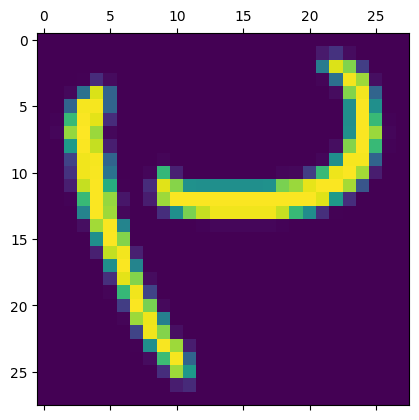

In [5]:
test_num = 10
plt.matshow(train_data[test_num])
print(chr(train_label[test_num] + 64))

모델 구성

In [6]:
model = models.Sequential([
    # 입력 레이어 명시 (TFLite 변환 시 입력 형태가 고정되어야 오류가 없습니다)
    layers.Input(shape=(28, 28, 1)),

    # 1st Block
    layers.Conv2D(8, kernel_size=(3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    # 2nd Block (크기 축소: 28x28 -> 14x14)
    layers.Conv2D(16, kernel_size=(3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # 3rd Block (크기 축소: 14x14 -> 7x7)
    layers.Conv2D(32, kernel_size=(3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # 과적합 방지
    layers.Dropout(0.25),
    
    # Flatten layer
    layers.Flatten(),
    # 최종 출력 (다중 분류이므로 softmax 활성화 함수 사용)
    layers.Dense(27, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │        42,363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,475 (189.36 KB)

 Trainable params: 48,363 (188.92 KB)

 Non-trainable params: 112 (448.00 B)

모델 컴파일 및 훈련

In [7]:
model.compile(optimizer='adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.fit(train_data, train_label, epochs=5)

Epoch 1/5
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.8341 - loss: 0.5329
Epoch 2/5
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.9025 - loss: 0.3007
Epoch 3/5
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.9154 - loss: 0.2575
Epoch 4/5
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - accuracy: 0.9229 - loss: 0.2314
Epoch 5/5
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - accuracy: 0.9285 - loss: 0.2147


모델 평가

In [10]:
model.evaluate(test_data, test_label, verbose=2)

650/650 - 2s - 2ms/step - accuracy: 0.9308 - loss: 0.2166


[0.2166396826505661, 0.9307692050933838]

모델 저장

In [ ]:
# !pip install tinymlgen
from tinymlgen import port

c_code = port(model, variable_name="testmodel2", pretty_print=True, optimize=False )
print(c_code)

# # 양자화 없이 모델을 텐서플로우 라이트 형식으로 변환
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# tflite_model = converter.convert()

# # 모델을 디스크에 저장
# open("model.tflite", "wb").write(tflite_model)
# # xxd를 사용할 수 없을 경우, 설치한다.
# !apt-get -qq install xxd
# # 파일을 C 소스파일로 저장
# !xxd -i model.tflite > model.cc
# # 소스파일을 출력
# !cat model.cc

# # 양자화하여 모델을 텐서플로우 라이트 형식으로 변환
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
# tflite_model = converter.convert()

# # 모델을 디스크에 저장
# open("quantize_Emodel.tflite", "wb").write(tflite_model)



#ifdef __has_attribute
#define HAVE_ATTRIBUTE(x) __has_attribute(x)
#else
#define HAVE_ATTRIBUTE(x) 0
#endif
#if HAVE_ATTRIBUTE(aligned) || (defined(__GNUC__) && !defined(__clang__))
#define DATA_ALIGN_ATTRIBUTE __attribute__((aligned(4)))
#else
#define DATA_ALIGN_ATTRIBUTE
#endif

const unsigned char testmodel2[] DATA_ALIGN_ATTRIBUTE = {
	0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00, 
	0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00, 
	0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 
	0x88, 0x00, 0x00, 0x00, 0xe0, 0x00, 0x00, 0x00, 0xb8, 0x46, 0x00, 0x00, 
	0xc8, 0x46, 0x00, 0x00, 0x28, 0x51, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00, 
	0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0xba, 0xb8, 0xff, 0xff, 
	0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x38, 0x00, 0x00, 0x00, 
	0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f, 
	0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00,